# **Payment System Market Forecasting**

7. Fit baseline SARIMA
8. Forecast future values
9. Evaluate predictions
10. Residual diagnostics

In [ ]:
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from statsmodels.tsa.seasonal import seasonal_decompose

from bcrp_analytics.bcrp_analyzer import BCRP_ANALYZER
from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

# Pandas display options
pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# Matplotlib theme
plt.style.use("mocha")

## 1. **Load data: Monto y número de operaciones procesadas por los adquirentes y facilitadores de pago por segmento de comercio (millones de soles y miles de operaciones)**

In [8]:
# series to test
adquirentes_facilitadores_pago_series = {
    "PN42689EM": "monto_total_adqfac",
    # instrumentos de pago de alto y bajo valor
    "PN42156EM": "alto_valor",
    "PN42160EM": "bajo_valor",
}

In [9]:
df_adquirentes_facilitadores = build_bcrp_dataset(adquirentes_facilitadores_pago_series)
df_adquirentes_facilitadores.head()

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/bcrp_analytics/utils.py:157: UserWarning: Warning: Some series contain missing ovservations due to selecting series with different data ranges
  warnings.warn("Warning: Some series contain missing ovservations due to selecting series with different data ranges")


,period,monto_total_adqfac,alto_valor,bajo_valor
0,2026-03-01,"13,167.96","478,458.55","417,155.45"
1,2026-02-01,"11,697.08","411,779.84","377,297.19"
2,2026-01-01,"12,252.01","398,930.84","394,384.29"
3,2025-12-01,"14,927.05","462,444.46","458,953.59"
4,2025-11-01,"12,200.23","398,541.09","374,481.11"


## **2. Visualize series**

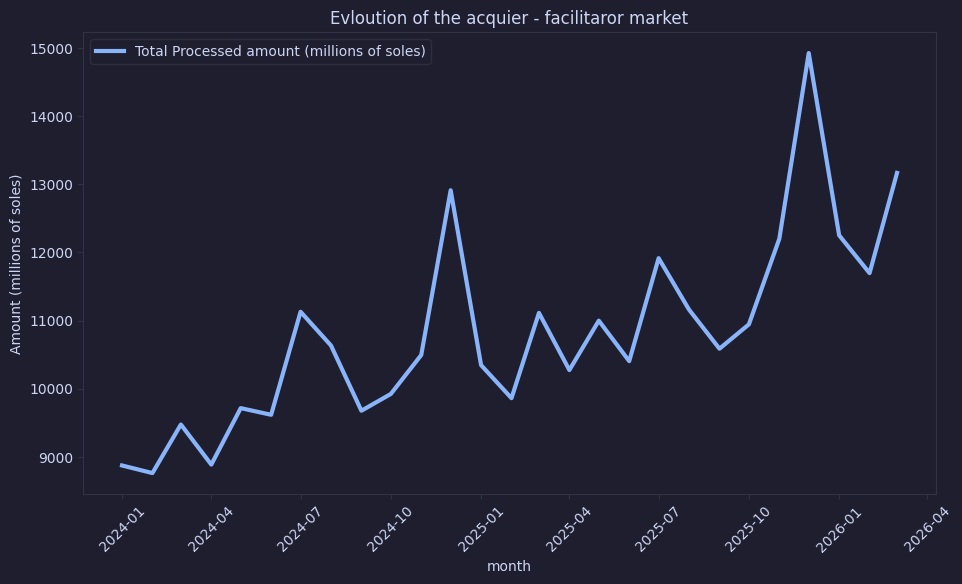

In [10]:
df_forecast = df_adquirentes_facilitadores[
    df_adquirentes_facilitadores["period"] >= "2024-01-01"
][["period", "monto_total_adqfac"]]
df_forecast = df_forecast.sort_values("period")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df_forecast["period"],
    df_forecast["monto_total_adqfac"],
    label="Total Processed amount (millions of soles)",
    linewidth=3,
)

ax.set_title("Evloution of the acquier - facilitaror market")

ax.legend()

ax.set_ylabel("Amount (millions of soles)")

ax.set_xlabel("month")
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
plt.xticks(rotation=45)

plt.show()

In [11]:
print(f"Number of observations in the serie: {(df_forecast["period"].size)}")

Number of observations in the serie: 27


# **3. Decompose seasonality**

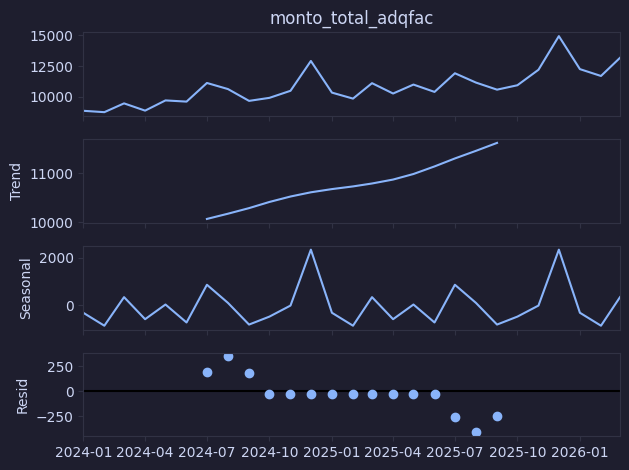

In [12]:
df_forecast = df_forecast.set_index("period")

decomposition = seasonal_decompose(
    df_forecast["monto_total_adqfac"], model="additive", period=12
)

decomposition.plot()

plt.show()

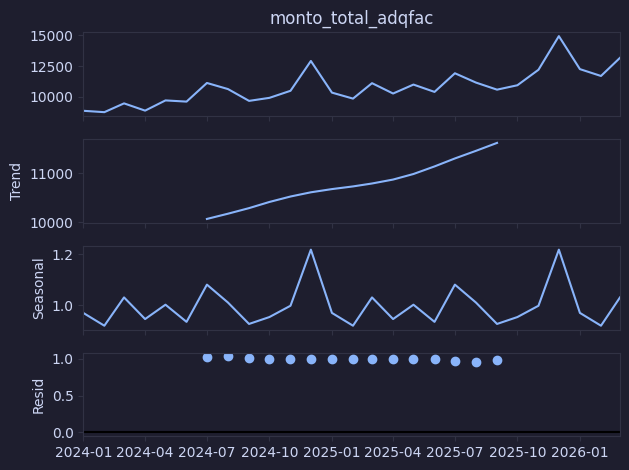

In [13]:
decomposition = seasonal_decompose(
    df_forecast["monto_total_adqfac"], model="multiplicative", period=12
)

decomposition.plot()

plt.show()

### Seasonality findings

- **Payment-System Series (`monto_total_adqfac`)**

Initial seasonal decomposition suggests:

- A clear positive long-term trend, indicating structural growth in the acq-fac market.
- Strong recurring seasonal patterns, especially around:
  - December,
  - and midyear periods ( related to July bonus effects in Peru).
- The multiplicative decomposition appears more appropriate than the additive version due to seasonal effects scale proportionally with market size.
- Residuals in the multiplicative model remain relatively stable around 1 indicating that trend and seasonality explain a huge proportion of the observed behavior

This suggests the series likely contains:
- trend,
- seasonality,
- and non-stationary behavior,

making it a suitable candidate for SARIMA and other forecasting models.

## **4. Test stationarity**

In [14]:
from statsmodels.tsa.stattools import adfuller

serie = df_forecast["monto_total_adqfac"]

adf_result = adfuller(serie)

print(f"ADF statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

ADF statistic: 0.888370279676677
p-value: 0.9929366629183267


In [15]:
# first differencing
serie_diff = serie.diff().dropna()

# apply ADF test to differenced series
adf_result = adfuller(serie_diff)

print("ADF test on differenced series")
print(f"ADF statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

ADF test on differenced series
ADF statistic: -1.4832974697329517
p-value: 0.5417570689280845


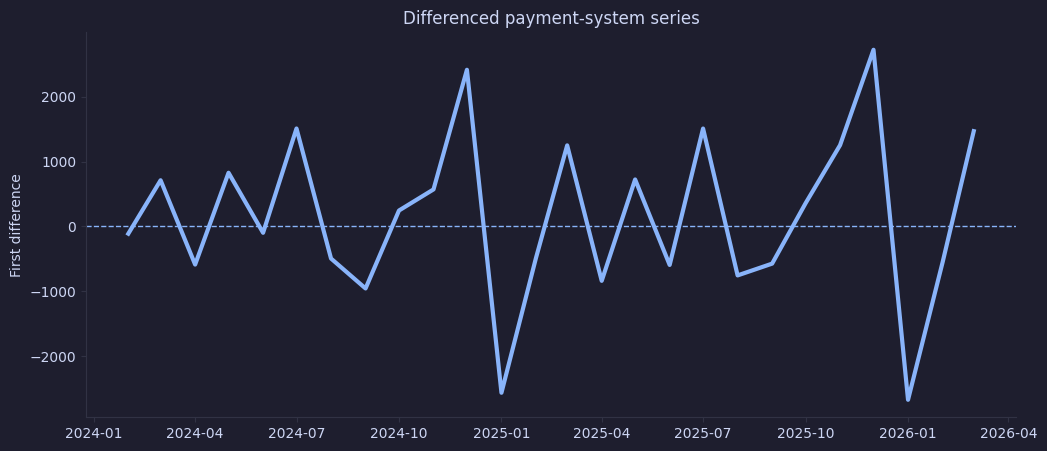

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df_forecast.index[1:],
    serie_diff,
    linewidth=3,
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Differenced payment-system series")
ax.set_ylabel("First difference")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Stationarity Analysis

- The ADF test failed to reject the null hypothesis of non stationarity for the original series

- After applying first differencing, the series visually appears more stable and oscillates around zer suggesting partial stationarity improvement.

- However, the ADF test on the differenced series still failed to reject non stationarity

- This may be influenced by:
  - the very small sample size (~27 monthly observations),
  - remaining seasonal effects,
  - and possible structural growth dynamics in the payment-system market.

- The series likely requires:
  - seasonal differencing,
  - or additional transformations,
  before fitting SARIMA models.

## **5. ACF/PACF**

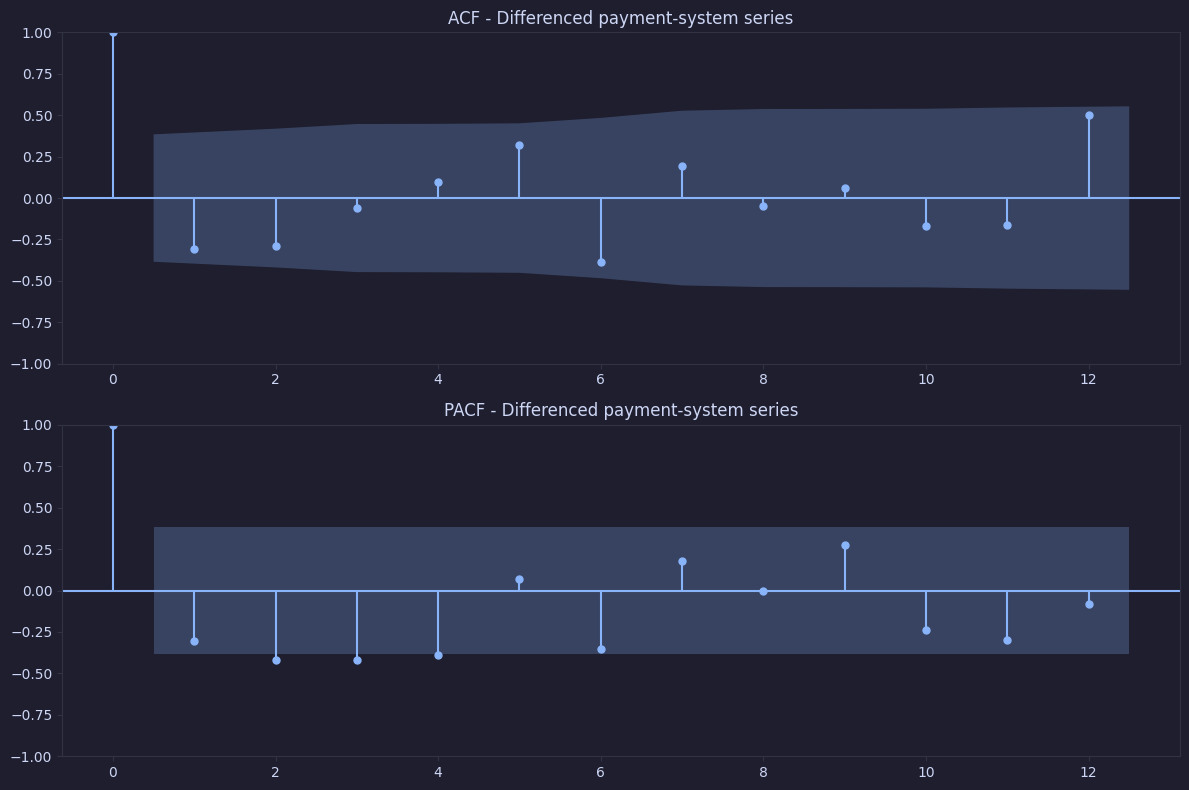

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie_diff = df_forecast["monto_total_adqfac"].dropna().diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(
    serie_diff,
    ax=axes[0],
    lags=12,
)

axes[0].set_title("ACF - Differenced payment-system series")

# PACF
plot_pacf(
    serie_diff,
    ax=axes[1],
    lags=12,
    method="ywm",
)

axes[1].set_title("PACF - Differenced payment-system series")

plt.tight_layout()

plt.show()

### ACF / PACF Analysis

- Insights after first differencing the serie: autocorrelation persistence was significantly reduced,suggesting that differencing helped stabilize the series.

- Most ACF spikes remained inside the confidence intervals, indicating weak statistical evidence of strong autocorrelation 

- A possible seasonal effect around lag 12 was still observed, consistent with the seasonal decomposition findings.

- PACF showed several significant short-run lags (around lags 2–4), suggesting possible autoregressive behavior in the series.

- Due to the limited sample size (27 monthly observations), these diagnostics should be interpreted as exploratory rather than conclusive

## **7. Fit baseline SARIMA**

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

serie = df_forecast["monto_total_adqfac"].dropna()

model = SARIMAX(serie, order=(1, 1, 0), seasonal_order=(0, 0, 0, 12))

results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:     monto_total_adqfac   No. Observations:                   27
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -222.349
Date:                Sat, 16 May 2026   AIC                            448.697
Time:                        12:31:56   BIC                            451.213
Sample:                    01-01-2024   HQIC                           449.422
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1814      0.144     -1.261      0.207      -0.463       0.100
sigma2      1.576e+06   4.55e+05      3.464      0.001    6.84e+05    2.47e+06
Ljung-Box (L1) (Q):                   1.09   Jarque-

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# **7. Forecast future avalues**

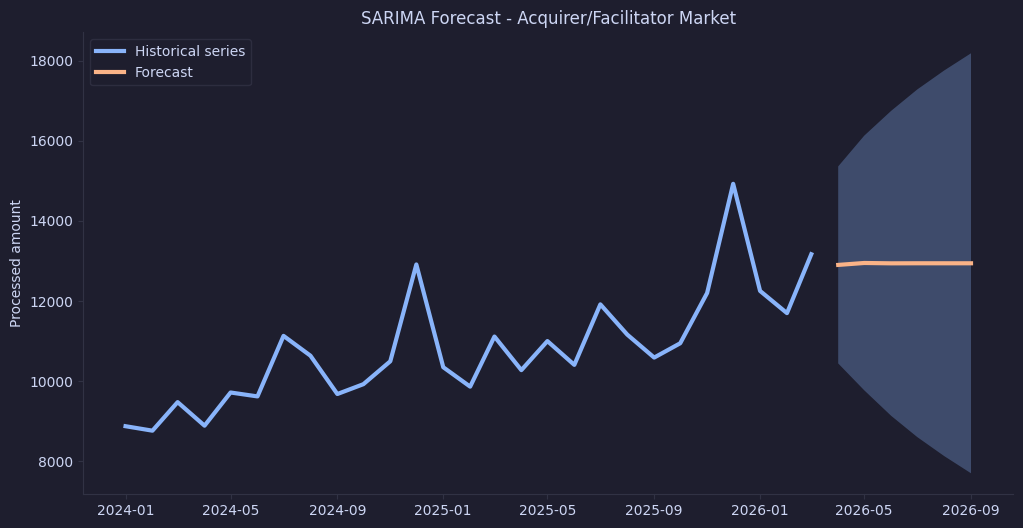

In [38]:
# forecast next 6 months
forecast_steps = 6

forecast_result = results.get_forecast(steps=forecast_steps)

# predicted mean
forecast_mean = forecast_result.predicted_mean

# confidence intervals
forecast_ci = forecast_result.conf_int()

# plot
fig, ax = plt.subplots(figsize=(12, 6))

# historical data
ax.plot(
    df_forecast.index,
    df_forecast["monto_total_adqfac"],
    label="Historical series",
    linewidth=3,
)

# forecast
ax.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    linewidth=3,
)

# confidence intervals
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3,
)

ax.set_title("SARIMA Forecast - Acquirer/Facilitator Market")

ax.set_ylabel("Processed amount")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()